In [ ]:
# ── MLOps bootstrap (auto-injected by inject_mlops_cell.py) ──────────────────
import os, warnings, mlflow
warnings.filterwarnings("ignore")

SEED = 42
import random, numpy as np
random.seed(SEED)
np.random.seed(SEED)
try:
    import torch; torch.manual_seed(SEED)
except ImportError:
    pass
try:
    import tensorflow as tf; tf.random.set_seed(SEED)
except ImportError:
    pass

_nb_name = os.path.basename(os.path.abspath("__file__") if "__file__" in dir() else ".").replace(".ipynb","")
mlflow.set_tracking_uri("sqlite:///" + str(Path(__file__).parent.parent.parent / "mlflow.db")
                        if "__file__" in dir() else "sqlite:///mlflow.db")
_exp = mlflow.set_experiment(_nb_name or "unnamed_notebook")
print(f"MLflow experiment: {_exp.name}")


In [ ]:
# --- Data Directory Setup (auto-generated) ---
from pathlib import Path
import os

# Resolve data directory relative to workspace root
def _find_data_dir():
    """Find the data directory by walking up from notebook location."""
    candidates = [
        Path.cwd().parent / "data" / "NLP Project 23. - Spam SMS Classification",
        Path.cwd() / "data" / "NLP Project 23. - Spam SMS Classification",
        Path(".").resolve().parent / "data" / "NLP Project 23. - Spam SMS Classification",
    ]
    for c in candidates:
        if c.exists():
            return c
    # Fallback: current directory
    return Path(".")

DATA_DIR = _find_data_dir()
print(f"Data directory: {DATA_DIR}")

In [1]:
# Importing essential libraries
import numpy as np
import pandas as pd

In [2]:
# Loading the dataset
df = pd.read_csv(str(DATA_DIR / 'Spam SMS Collection'), sep='\t', names=['label', 'message'])

# **Exploratory Data Analysis (EDA)**
* Exploring NaN values in dataset
* Plotting countplots for Spam vs. Ham



In [3]:
df.shape

(5572, 2)

In [4]:
df.columns

Index(['label', 'message'], dtype='object')

In [5]:
df.dtypes

label      object
message    object
dtype: object

In [6]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.tail()

,label,message
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [9]:
df.describe(include='object')

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


_**Note: No NaN values** in the dataset._

In [10]:
# Mapping values for label
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [11]:
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
df.tail()

,label,message
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will ü b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...
5571,0,Rofl. Its true to its name


In [13]:
# Importing essential libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


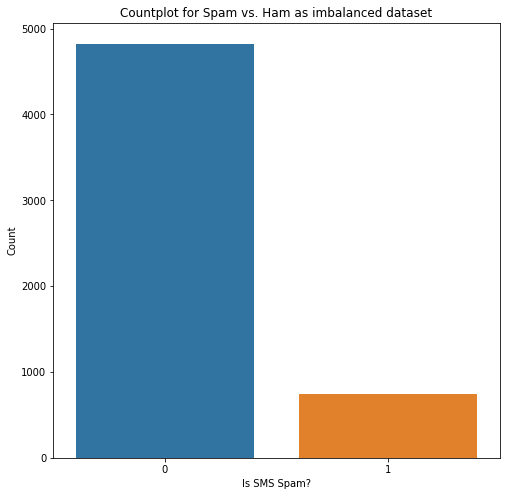

In [14]:
# Countplot for Spam vs. Ham as imbalanced dataset
plt.figure(figsize=(8,8))
g = sns.countplot(x='label', data=df)
p = plt.title('Countplot for Spam vs. Ham as imbalanced dataset')
p = plt.xlabel('Is SMS Spam?')
p = plt.ylabel('Count')

_**Insight:** From the above countplot, it is evident that the **dataset is imbalanced**._

# **Feature Engineering**
*   Handling imbalanced dataset using Oversampling
*   Creating new features e.g. word_count, contains_currency_symbol, contains_numbers, etc.



In [15]:
# Handling imbalanced dataset using Oversampling
only_spam = df[df['label']==1]
print('Number of Spam records: {}'.format(only_spam.shape[0]))
print('Number of Ham records: {}'.format(df.shape[0]-only_spam.shape[0]))

Number of Spam records: 747
Number of Ham records: 4825


In [16]:
count = int((df.shape[0]-only_spam.shape[0])/only_spam.shape[0])
for i in range(0, count-1):
  df = pd.concat([df, only_spam])

df.shape

(9307, 2)

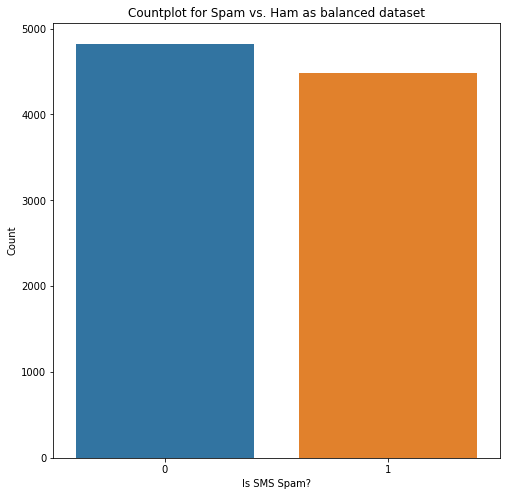

In [17]:
# Countplot for Spam vs. Ham as balanced dataset
plt.figure(figsize=(8,8))
g = sns.countplot(x='label', data=df)
p = plt.title('Countplot for Spam vs. Ham as balanced dataset')
p = plt.xlabel('Is SMS Spam?')
p = plt.ylabel('Count')

In [18]:
# Creating new feature word_count
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

In [19]:
df.head()

,label,message,word_count
0,0,"Go until jurong point, crazy.. Available only ...",20
1,0,Ok lar... Joking wif u oni...,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,28
3,0,U dun say so early hor... U c already then say...,11
4,0,"Nah I don't think he goes to usf, he lives aro...",13


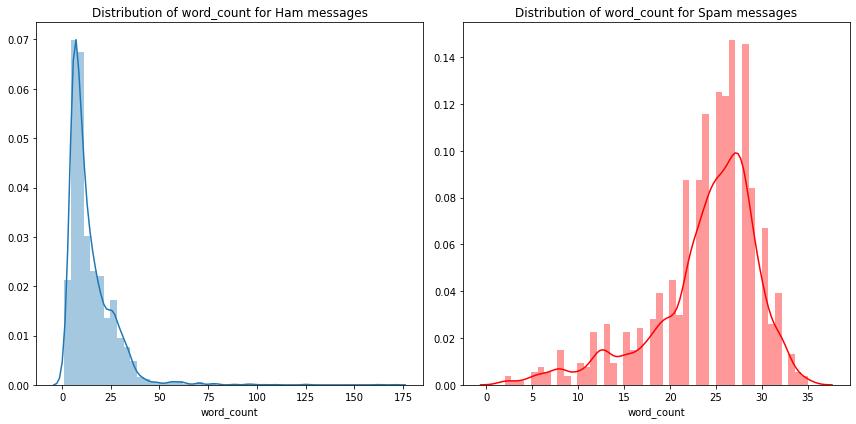

In [20]:
plt.figure(figsize=(12, 6))

# 1-row, 2-column, go to the first subplot
plt.subplot(1, 2, 1)
g = sns.distplot(a=df[df['label']==0].word_count)
p = plt.title('Distribution of word_count for Ham messages')

# 1-row, 2-column, go to the second subplot
plt.subplot(1, 2, 2)
g = sns.distplot(a=df[df['label']==1].word_count, color='red')
p = plt.title('Distribution of word_count for Spam messages')

plt.tight_layout()
plt.show()

_**Insight:** **Spam messages** word_count fall in the range of **15-30 words**, whereas majority of the **Ham messages** fall in the range of **below 25 words**._

In [21]:
# Creating feature contains_currency_symbol
def currency(x):
  currency_symbols = ['€', '$', '¥', '£', '₹']
  for i in currency_symbols:
    if i in x:
      return 1
  return 0

df['contains_currency_symbol'] = df['message'].apply(currency)

In [22]:
df.tail()

,label,message,word_count,contains_currency_symbol
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...,16,0
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,33,1
5547,1,Had your contract mobile 11 Mnths? Latest Moto...,28,0
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...,28,0
5567,1,This is the 2nd time we have tried 2 contact u...,30,1


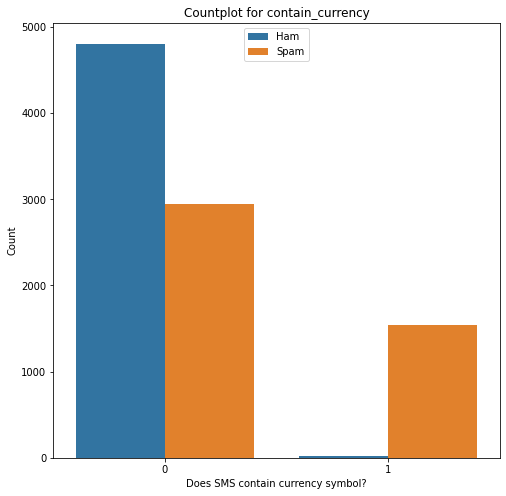

In [23]:
# Countplot for contains_currency_symbol
plt.figure(figsize=(8,8))
g = sns.countplot(x='contains_currency_symbol', data=df, hue='label')
p = plt.title('Countplot for contain_currency')
p = plt.xlabel('Does SMS contain currency symbol?')
p = plt.ylabel('Count')
p = plt.legend(labels=['Ham', 'Spam'], loc=9)

_**Insight: Almost 1/3 of Spam messages contain currency symbols**, and currency symbols are **rarely used in Ham messages.**_

In [24]:
# Creating feature contains_number
def numbers(x):
  for i in x:
    if ord(i)>=48 and ord(i)<=57:
      return 1
  return 0

df['contains_number'] = df['message'].apply(numbers)

In [25]:
df.head()

,label,message,word_count,contains_currency_symbol,contains_number
0,0,"Go until jurong point, crazy.. Available only ...",20,0,0
1,0,Ok lar... Joking wif u oni...,6,0,0
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,28,0,1
3,0,U dun say so early hor... U c already then say...,11,0,0
4,0,"Nah I don't think he goes to usf, he lives aro...",13,0,0


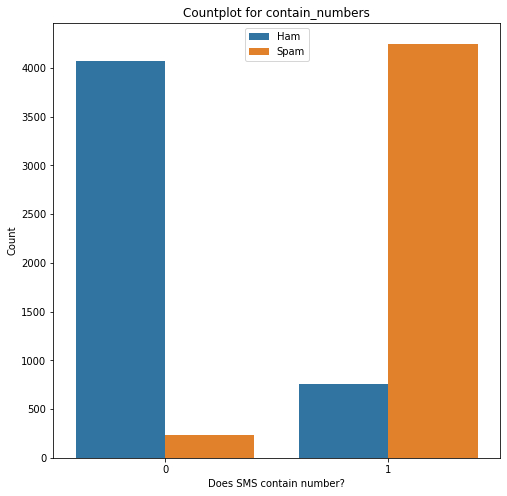

In [26]:
# Countplot for contains_number
plt.figure(figsize=(8,8))
g = sns.countplot(x='contains_number', data=df, hue='label')
p = plt.title('Countplot for contain_numbers')
p = plt.xlabel('Does SMS contain number?')
p = plt.ylabel('Count')
p = plt.legend(labels=['Ham', 'Spam'], loc=9)

_**Insight:** It is evident that **most of the Spam messages contain numbers,** and **majority of the Ham messages donot contain numbers.**_

# **Data Cleaning**
* Removing special character and numbers using regular expression
* Converting the entire sms into lower case
* Tokenizing the sms by words
* Removing the stop words
* Lemmatizing the words
* Joining the lemmatized words
* Building a corpus of messages

In [27]:
# Importing essential libraries for performing NLP
import nltk
import re
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [28]:
# Cleaning the messages
corpus = []
wnl = WordNetLemmatizer()

for sms_string in list(df.message):

  # Cleaning special character from the sms
  message = re.sub(pattern='[^a-zA-Z]', repl=' ', string=sms_string)

  # Converting the entire sms into lower case
  message = message.lower()

  # Tokenizing the sms by words
  words = message.split()

  # Removing the stop words
  filtered_words = [word for word in words if word not in set(stopwords.words('english'))]

  # Lemmatizing the words
  lemmatized_words = [wnl.lemmatize(word) for word in filtered_words]

  # Joining the lemmatized words
  message = ' '.join(lemmatized_words)

  # Building a corpus of messages
  corpus.append(message)

In [29]:
corpus[0:3]

['go jurong point crazy available bugis n great world la e buffet cine got amore wat',
 'ok lar joking wif u oni',
 'free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate c apply']

In [30]:
# Creating the Bag of Words model
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=500)
vectors = tfidf.fit_transform(corpus).toarray()
feature_names = tfidf.get_feature_names()

# Extracting independent and dependent variables from the dataset
X = pd.DataFrame(vectors, columns=feature_names)
y = df['label']

---
# Standardized ML Pipeline

**Step 1** — LazyPredict: automated baseline comparison of dozens of models  
**Step 2** — PyCaret: automated final pipeline (setup → compare → finalize)


In [ ]:
# ── STEP 1: LazyPredict — Baseline Model Comparison ──
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

_X = X.toarray() if hasattr(X, 'toarray') else np.array(X) if not isinstance(X, np.ndarray) else X
_y = np.array(y).ravel()

X_train, X_test, y_train, y_test = train_test_split(_X, _y, test_size=0.2, random_state=42)

clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)
print(models)

# ── Metrics Extraction ──
best_model_name = models.sort_values('Accuracy', ascending=False).index[0]
_best_row = models.loc[best_model_name]
lp_accuracy = float(_best_row.get('Accuracy', 0))
lp_f1 = float(_best_row.get('F1 Score', 0))
print(f'\n>>> Best LazyPredict model: {best_model_name}')
print(f'    Accuracy={lp_accuracy:.4f}  F1={lp_f1:.4f}')


In [ ]:
# ── STEP 2: PyCaret — Final Pipeline ──
from pycaret.classification import setup, compare_models, finalize_model, pull

# Prepare DataFrame (sample if needed for speed)
_max_rows, _max_cols = 5000, 2000
_X_sub = _X[:_max_rows, :min(_X.shape[1], _max_cols)]
_y_sub = _y[:_max_rows]

df_ml = pd.DataFrame(_X_sub, columns=[f'f{i}' for i in range(_X_sub.shape[1])])
df_ml['target'] = _y_sub

s = setup(data=df_ml, target='target', session_id=42, verbose=False)
best = compare_models(n_select=1)
pycaret_results = pull()
print(pycaret_results)

final_model = finalize_model(best)
pycaret_model_name = type(best).__name__

# Extract PyCaret metrics
_pc_best = pycaret_results.iloc[0]
pc_accuracy = float(_pc_best.get('Accuracy', 0))
pc_precision = float(_pc_best.get('Prec.', 0))
pc_recall = float(_pc_best.get('Recall', 0))
pc_f1 = float(_pc_best.get('F1', 0))

print(f'\nPyCaret Best: {pycaret_model_name}')
print(f'  Accuracy={pc_accuracy:.4f}  Precision={pc_precision:.4f}  Recall={pc_recall:.4f}  F1={pc_f1:.4f}')


---
## Model Governance — Persistence & Registry

Save trained model, feature vectorizer, metrics, and register in global project registry.


In [ ]:
import json, os
from datetime import datetime
from pathlib import Path
from joblib import dump

project_name = 'spam_sms_classification'
_artifacts_dir = Path('..') / 'artifacts' / project_name
_artifacts_dir.mkdir(parents=True, exist_ok=True)

# Save trained model
dump(final_model, str(_artifacts_dir / 'model.joblib'))

# Save feature vectorizer
dump(tfidf, str(_artifacts_dir / 'vectorizer.joblib'))

# Save metrics
_metrics = {
    'best_model_lazypredict': best_model_name,
    'pycaret_model': pycaret_model_name,
    'accuracy': pc_accuracy,
    'f1': pc_f1,
    'precision': pc_precision,
    'recall': pc_recall,
    'lp_accuracy': lp_accuracy,
    'lp_f1': lp_f1,
}
with open(str(_artifacts_dir / 'metrics.json'), 'w') as f:
    json.dump(_metrics, f, indent=2)

# Update global registry
_registry_path = Path('..') / 'artifacts' / 'global_registry.json'
_registry_path.parent.mkdir(parents=True, exist_ok=True)
if _registry_path.exists():
    with open(str(_registry_path)) as f:
        _registry = json.load(f)
else:
    _registry = []
_registry = [e for e in _registry if e.get('project') != project_name]
_registry.append({
    'project': project_name,
    'best_model': best_model_name,
    'pycaret_model': pycaret_model_name,
    'accuracy': pc_accuracy,
    'timestamp': datetime.now().isoformat(),
})
with open(str(_registry_path), 'w') as f:
    json.dump(_registry, f, indent=2)

print(f'Artifacts saved to {_artifacts_dir}/')


In [ ]:
# ── Inference Function ──
def predict_text(text):
    """Run inference on a single text input."""
    vec = tfidf.transform([text])
    return final_model.predict(vec)

print('Inference function ready: predict_text(text)')


In [ ]:
# ── Consistency Checks ──
assert final_model is not None, 'Final model was not created'
assert best_model_name is not None, 'Best model name was not captured'
assert (_artifacts_dir / 'model.joblib').exists(), 'Model file not saved'
assert (_artifacts_dir / 'metrics.json').exists(), 'Metrics file not saved'

# ── Summary ──
print('=' * 50)
print('MODEL GOVERNANCE SUMMARY')
print('=' * 50)
print(f'Project:              {project_name}')
print(f'Best Model (LP):      {best_model_name}')
print(f'Best Model (PyCaret): {pycaret_model_name}')
print(f'Accuracy:             {pc_accuracy:.4f}')
print(f'Precision:            {pc_precision:.4f}')
print(f'Recall:               {pc_recall:.4f}')
print(f'F1 Score:             {pc_f1:.4f}')
print(f'Artifacts:            {_artifacts_dir}/')
print('=' * 50)
